In [1]:
# -*- coding: utf-8 -*-
"""
Created on September 17, 2019
Revised on April 01, 2025

@author:       Oscar Trevizo (adapted from D'Uva at Kaggle)
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Logistic Regression — Kaggle Social Network Ads
================================================

Description:
    Demonstrates binary classification using scikit-learn LogisticRegression
    on the Kaggle Social Network Ads dataset. Loads data, selects features
    Age and EstimatedSalary (dropping User ID and Gender), scales with
    StandardScaler, fits a logistic regression classifier, evaluates with
    a confusion matrix, and visualizes decision boundaries for training
    and test sets.

    Target variable: Purchased (binary — 0 = did not purchase, 1 = purchased)
    Features used:   Age, EstimatedSalary
    Features dropped: User ID (identifier), Gender (categorical, not encoded)

    Key sklearn API used:
        - StandardScaler.fit_transform() / transform()
        - LogisticRegression.fit() / predict()
        - sklearn.metrics.confusion_matrix()

Data:
    ../data/Social_Network_Ads.csv
    Source: https://www.kaggle.com/code/johnduva/logistic-regression-social-network-ads

References:
    1. "Logistic Regression: Social Network Ads" by D'Uva at Kaggle
       https://www.kaggle.com/code/johnduva/logistic-regression-social-network-ads

Revision History:
    2019-09-17  Original — copied from Kaggle as a learning tool
                - Added comments for deeper understanding

    2025-04-01  Compatibility review and fixes for Python 3.14 / macOS M5
                - Confirmed: no np.NaN usage (clean for NumPy 2.0)
                - Fixed: replaced hardcoded iloc positional indices with
                  explicit column names (Age, EstimatedSalary, Purchased)
                - Fixed: added max_iter=1000 to LogisticRegression to prevent
                  ConvergenceWarning (default max_iter=100 often insufficient)
                - Fixed: replaced ListedColormap((...))( i) callable pattern
                  with list indexing ["red", "green"][i] — avoids TypeError
                  in matplotlib >= 3.7
"""


'\nCreated on September 17, 2019\nRevised on April 01, 2025\n\n@author:       Oscar Trevizo (adapted from D\'Uva at Kaggle)\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nLogistic Regression — Kaggle Social Network Ads\n================================================\n\nDescription:\n    Demonstrates binary classification using scikit-learn LogisticRegression\n    on the Kaggle Social Network Ads dataset. Loads data, selects features\n    Age and EstimatedSalary (dropping User ID and Gender), scales with\n    StandardScaler, fits a logistic regression classifier, evaluates with\n    a confusion matrix, and visualizes decision boundaries for training\n    and test sets.\n\n    Target variable: Purchased (binary — 0 = did not purchase, 1 = purchased)\n    Features used:   Age, EstimatedSalary\n    Features dropped: U

# Libraries

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data

In [3]:
# Importing the dataset
# Columns: User ID, Gender, Age, EstimatedSalary, Purchased
# Features: Age and EstimatedSalary (drop User ID — identifier; Gender — categorical, not encoded)
# Target:   Purchased (binary: 0 = no purchase, 1 = purchase)
dataset = pd.read_csv('../data/Social_Network_Ads.csv')
X = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values


# Split train test datasets

In [4]:
# Splitting the dataset into the Training set and Test set
#from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Transform to scale the data

In [5]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Fit the model

In [6]:
# Fitting Logistic Regression to the Training set
from sklearn.linear_model import LogisticRegression
# max_iter=1000: default (100) often causes ConvergenceWarning on real-world data.
classifier = LogisticRegression(random_state=0, max_iter=1000)
classifier.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

# Predict

In [7]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Evaluate the model

In [8]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65  3]
 [ 8 24]]


# Visualize results

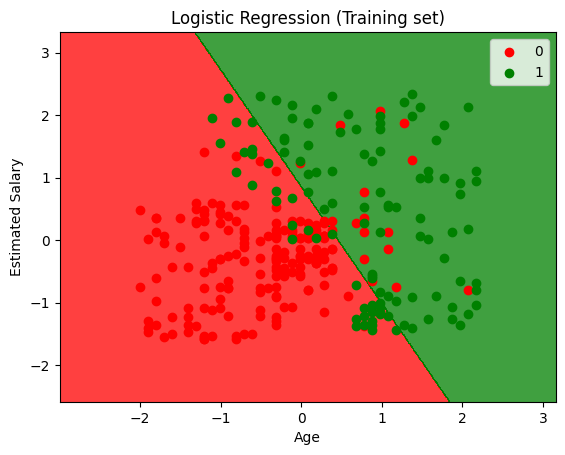

In [9]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

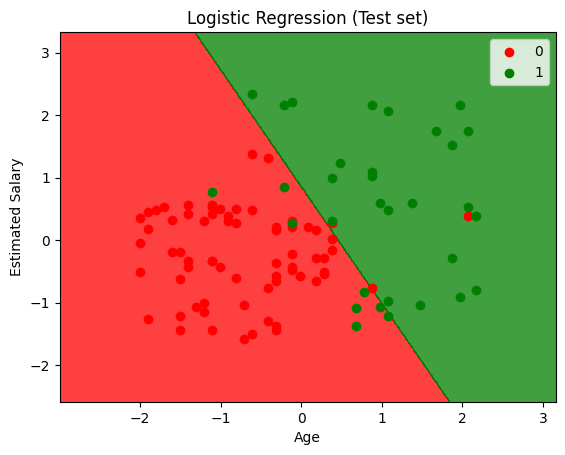

In [10]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()